## Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

## Load Dataset

In [25]:
df=pd.read_csv(r"D:\Project\Supermart-Sales-Analytics\Supermart-Grocery-Sales-Retail-Analytics-Dataset.csv")
print(df.head())
print(df.shape)
print(df.info())

  Order ID Customer Name          Category      Sub Category         City  \
0      OD1        Harish      Oil & Masala           Masalas      Vellore   
1      OD2         Sudha         Beverages     Health Drinks  Krishnagiri   
2      OD3       Hussain       Food Grains      Atta & Flour   Perambalur   
3      OD4       Jackson  Fruits & Veggies  Fresh Vegetables   Dharmapuri   
4      OD5       Ridhesh       Food Grains   Organic Staples         Ooty   

   Order Date Region  Sales  Discount  Profit       State  
0  08-11-2017  North   1254      0.12  401.28  Tamil Nadu  
1  08-11-2017  South    749      0.18  149.80  Tamil Nadu  
2  12-06-2017   West   2360      0.21  165.20  Tamil Nadu  
3  11-10-2016  South    896      0.25   89.60  Tamil Nadu  
4  11-10-2016  South   2355      0.26  918.45  Tamil Nadu  
(9994, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------    

## Data Cleaning

In [26]:
print(df.isnull().sum())


Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64


In [46]:
df = df.dropna(subset=['Order Date'])

In [47]:
df.isnull().sum()

Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
Year             0
Month            0
Month Name       0
Quarter          0
Day              0
dtype: int64

In [48]:
df.isna().sum()

Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
Year             0
Month            0
Month Name       0
Quarter          0
Day              0
dtype: int64

In [49]:
df.drop_duplicates(inplace=True)

In [50]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    errors='coerce'
)

## Feature Engineering

In [52]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Quarter'] = df['Order Date'].dt.quarter
df['Day'] = df['Order Date'].dt.day

## Exploratory Data Analysis

In [33]:
print("Total Sales :",df['Sales'].sum())

Total Sales : 14956982


In [34]:
print("Total Profit :",df['Profit'].sum())

Total Profit : 3747121.1999999997


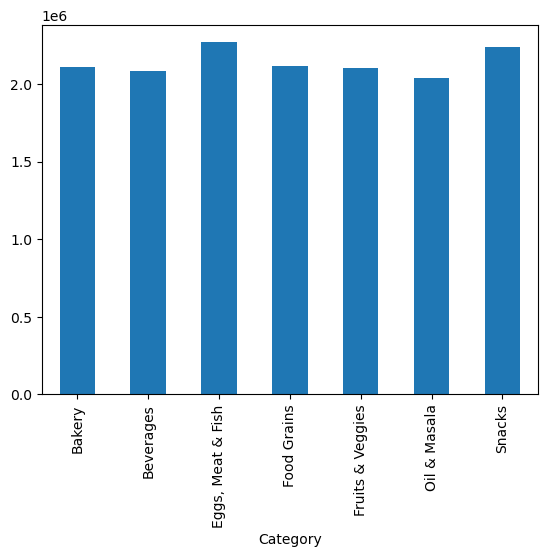

In [35]:
# Category Sales
category_sales = df.groupby('Category')['Sales'].sum()
category_sales.plot(kind='bar')
plt.show()

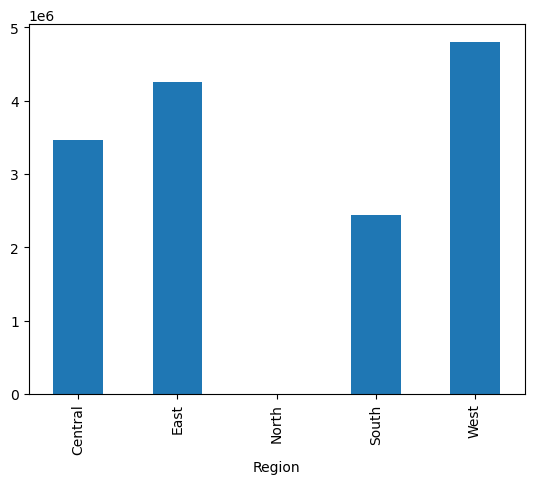

In [36]:
# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum()
region_sales.plot(kind='bar')
plt.show()

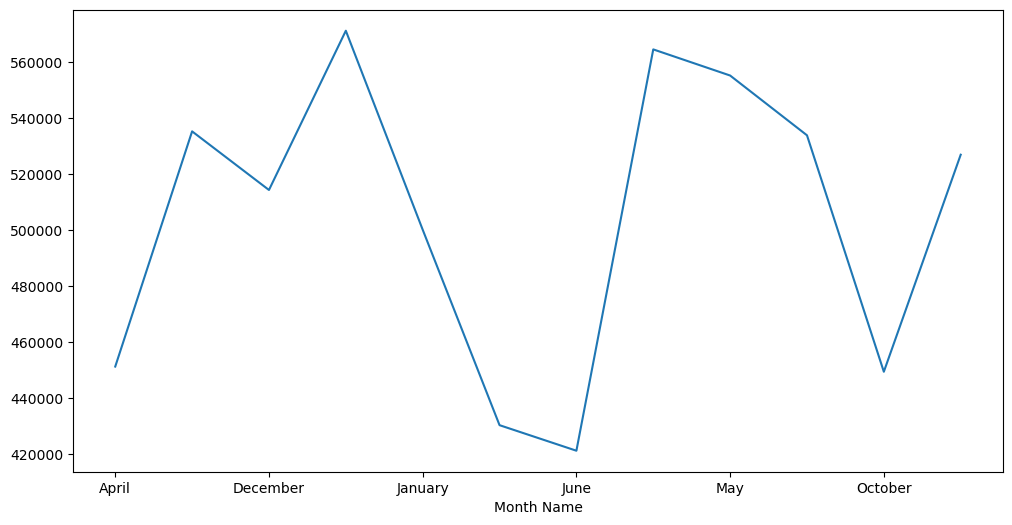

In [37]:
# Monthly Sales Trend
monthly_sales = df.groupby('Month Name')['Sales'].sum()
monthly_sales.plot(figsize=(12,6))
plt.show()

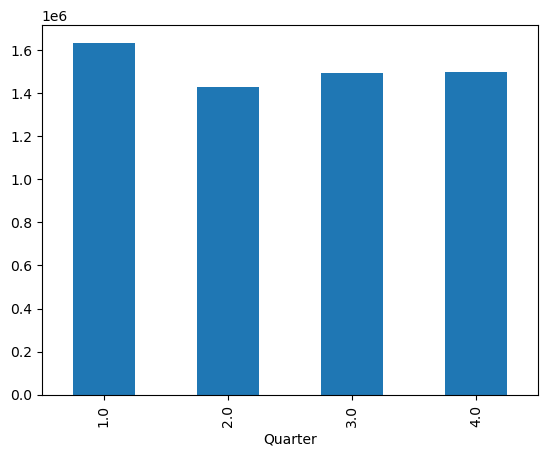

In [38]:
# Quarterly Sales
quarterly_sales = df.groupby('Quarter')['Sales'].sum()
quarterly_sales.plot(kind='bar')
plt.show()

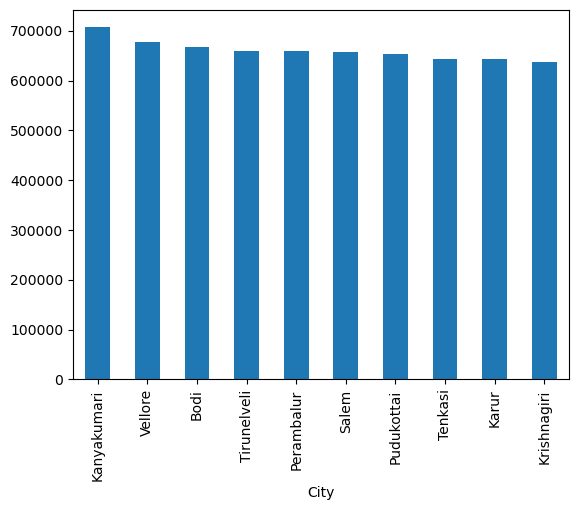

In [39]:
# Top 10 Cities
top_city = df.groupby('City')['Sales'].sum().nlargest(10)
top_city.plot(kind='bar')
plt.show()

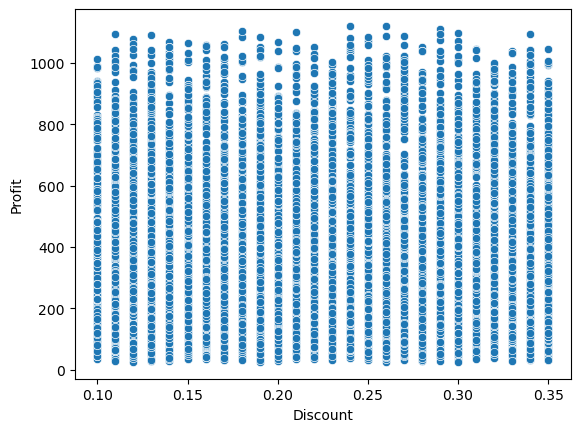

In [40]:
# Discount vs Profit
sns.scatterplot(data=df,x='Discount',y='Profit')
plt.show()

## Encode Categorical Columns

In [54]:
le = LabelEncoder()
cat_cols = ['Category','Sub Category','City','Region','State']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

## Prepare Features

In [58]:
y = df['Profit']
X = df[['Sales','Discount','Category','Sub Category','City','Region','State','Month','Quarter']]

In [59]:
X.isnull().sum()

Sales           0
Discount        0
Category        0
Sub Category    0
City            0
Region          0
State           0
Month           0
Quarter         0
dtype: int64

## Train Test Split

In [60]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Model -01 Linear Regression

In [64]:
lr = LinearRegression()
lr.fit(X_train,y_train)
pred_lr = lr.predict(X_test)
print("R2 Score :",r2_score(y_test,pred_lr))
print("MAE :",mean_absolute_error(y_test,pred_rf))
print("MSE :",mean_squared_error(y_test,pred_rf))

R2 Score : 0.3723834942732752
MAE : 158.23014079110013
MSE : 40041.43047953715


## Model -02 Random Forest

In [65]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)
print("R2 Score :",r2_score(y_test,pred_rf))
print("MAE :",mean_absolute_error(y_test,pred_rf))
print("MSE :",mean_squared_error(y_test,pred_rf))

R2 Score : 0.28157142210207875
MAE : 158.23014079110013
MSE : 40041.43047953715


## Model -03 XGBoost

In [66]:
xgb = XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=6,random_state=42)
xgb.fit(X_train,y_train)
pred_xgb = xgb.predict(X_test)
print("R2 score :",r2_score(y_test,pred_xgb))
print("MAE :",mean_absolute_error(y_test,pred_rf))
print("MSE :",mean_squared_error(y_test,pred_rf))

R2 score : 0.28445398342006667
MAE : 158.23014079110013
MSE : 40041.43047953715


## Model Comparison

In [67]:
models = pd.DataFrame({"Model":["Linear Regression","Random Forest","XGBoost"],
                       "R2":[r2_score(y_test,pred_lr),
                             r2_score(y_test,pred_rf),
                             r2_score(y_test,pred_xgb)
                            ]
                      })
print(models)

               Model        R2
0  Linear Regression  0.372383
1      Random Forest  0.281571
2            XGBoost  0.284454


## Save Best Model

In [71]:
'''import pickle
pickle.dump(xgb,
            open("profit_model.pkl","wb")
           )'''
import pickle
from sklearn.preprocessing import LabelEncoder

# Create and fit the encoders during training
cat_encoder = LabelEncoder()
df['Category'] = cat_encoder.fit_transform(df['Category'])

city_encoder = LabelEncoder()
df['City'] = city_encoder.fit_transform(df['City'])

# Save your model AND your encoders
with open("profit_model.pkl", "wb") as f:
    pickle.dump(xgb, f)

with open("cat_encoder.pkl", "wb") as f:
    pickle.dump(cat_encoder, f)

with open("city_encoder.pkl", "wb") as f:
    pickle.dump(city_encoder, f)